In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
from obsutils.utils import SkyportalClient

In [2]:
request = "2026_03_23T11_07_05.013"
request = "ZTF26aaonmha"

key = "MAG_PSF"
err_key = f"err{key}"

# key="magap5"
# err_key = "sigmagap5"

In [3]:
winter_data_dir = Path.home() / "Downloads/" / request

In [4]:
send_to_fritz = True
instrument_id = 1087 # WINTER is 46

In [5]:
paths = list(winter_data_dir.glob("*.csv"))
assert len(paths) < 2, "Multiple matching files"
path = paths[0]

In [6]:
df = pd.read_csv(path)
df["skyportal_filter"] = df["FILTER"].map({"J": "2massj", "H": "2massh", "Y": "ps1::y"})
df[["DATE-OBS", key, err_key, "FILTER", "MAGLIM"]]

,DATE-OBS,MAG_PSF,errMAG_PSF,FILTER,MAGLIM
0,2026-03-24T04:16:14.274,18.803359,0.113634,J,19.593372
1,2026-03-27T02:55:53.833,18.262251,0.144182,J,18.700701
2,2026-03-29T03:40:04.366,NaN,NaN,H,18.102853
3,2026-03-30T03:27:34.020,NaN,NaN,H,18.226318
4,2026-04-08T05:49:55.915,17.529508,0.097297,J,18.975284
5,2026-04-17T05:05:19.241,17.597107,0.106622,J,18.687874


In [7]:
df

,ra,dec,prv_candidates,objectid,xpos,ypos,fluxap5,fluxuncap5,magap5,sigmagap5,...,ZP,ZPSTD,MJD,MAG_POINTSOURCE,errMAG_POINTSOURCE,MAG_PSF,errMAG_PSF,MAG_AUTO,errMAG_AUTO,skyportal_filter
0,149.928661,0.418446,Empty DataFrame\nColumns: []\nIndex: [],NaN,1338.929799,443.952587,867.595701,81.164873,18.319666,0.103834,...,25.665460,0.021436,61123.177943,18.785877,0.127715,18.803359,0.113634,17.559175,0.175620,2massj
1,149.928661,0.418446,Empty DataFrame\nColumns: []\nIndex: [],NaN,1342.651360,479.843527,1170.583819,150.783892,18.061418,0.141413,...,25.732424,0.020705,61126.122151,18.220894,0.113784,18.262251,0.144182,17.619184,0.218279,2massj
2,149.928661,0.418446,Empty DataFrame\nColumns: []\nIndex: [],NaN,1350.699935,457.220522,198.601449,78.758091,18.521198,0.430865,...,24.266154,0.013037,61128.152828,NaN,NaN,NaN,NaN,NaN,NaN,2massh
3,149.928661,0.418446,Empty DataFrame\nColumns: []\nIndex: [],NaN,1356.586112,457.455336,251.984836,79.998834,18.365049,0.345045,...,24.368485,0.013593,61129.144144,NaN,NaN,NaN,NaN,NaN,NaN,2massh
4,149.928661,0.418446,Empty DataFrame\nColumns: []\nIndex: [],NaN,1332.874292,463.428125,1973.832584,122.194521,17.414039,0.071459,...,25.652315,0.024213,61138.243008,17.525060,0.082748,17.529508,0.097297,17.140592,0.157213,2massj
5,149.928661,0.418446,Empty DataFrame\nColumns: []\nIndex: [],NaN,1348.492563,462.866748,1722.270782,138.827439,17.440369,0.091423,...,25.530622,0.026364,61147.212028,17.582760,0.094079,17.597107,0.106622,17.256707,0.166482,2massj


In [8]:
mask = (df[err_key] < 0.5) & (df[key] < df["MAGLIM"])
df = df[mask].reset_index(drop=True)
df[["DATE-OBS", "FILTER", key, err_key, "MAGLIM"]]

,DATE-OBS,FILTER,MAG_PSF,errMAG_PSF,MAGLIM
0,2026-03-24T04:16:14.274,J,18.803359,0.113634,19.593372
1,2026-03-27T02:55:53.833,J,18.262251,0.144182,18.700701
2,2026-04-08T05:49:55.915,J,17.529508,0.097297,18.975284
3,2026-04-17T05:05:19.241,J,17.597107,0.106622,18.687874


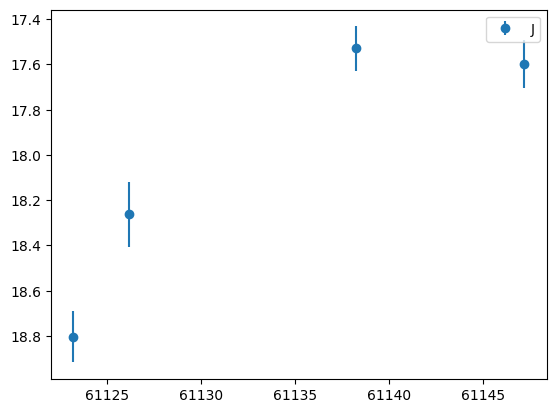

In [9]:
filters = set(df["FILTER"])

plt.figure()

# Plot each filter separately
for f in filters:
    df_cut = df[df["FILTER"] == f]
    plt.errorbar(df_cut["MJD"], df_cut[key], yerr=df_cut[err_key], fmt="o", label=f)

plt.gca().invert_yaxis()
plt.legend()

In [10]:
client = SkyportalClient()
client.set_up_session()

In [11]:
def get_skyportal_names(ra: float, dec: float, radius_arcsec: float = 1.5):

    res = client.api(
        "GET",
        "source_exists/",
        data={
            "ra": ra,
            "dec": dec,
            "radius": radius_arcsec/3600.0
        }
    )
    res.raise_for_status()


    sources = res.json()["data"]["message"].split(":")[-1].strip()[:-1].split(",")
    return sources


In [12]:
names = get_skyportal_names(df["ra"].iloc[0], df["dec"].iloc[0])

In [13]:
ORIGIN = "winter-fp"

if send_to_fritz:

    for name in names:
        print(name)

        payload = {
            "mjd": df["MJD"].to_list(),
            "filter": df["skyportal_filter"].to_list(),
            "obj_id": name.strip(),
            "instrument_id": instrument_id,
            "ra": df["ra"].to_list(),
            "dec": df["dec"].to_list(),
            "ra_unc": None,
            "dec_unc": None,
            "origin": ORIGIN,
            "group_ids": [1],
            "magsys": "ab",
            "mag": df[key].fillna('').to_list(),
            "magerr": df[f"err{key}"].fillna('').to_list(),
            "limiting_mag": df["MAGLIM"].to_list(),
            "limiting_mag_nsigma": 3,
        }
        print(payload)
        res = client.api(
            "PUT",
            "photometry",
            data=payload
        )
        print(res.json())
        res.raise_for_status()

2018mtl
{'mjd': [61123.17794298611, 61126.12215084491, 61138.243008275465, 61147.21202825232], 'filter': ['2massj', '2massj', '2massj', '2massj'], 'obj_id': '2018mtl', 'instrument_id': 1087, 'ra': [149.928661, 149.928661, 149.928661, 149.928661], 'dec': [0.418446, 0.418446, 0.418446, 0.418446], 'ra_unc': None, 'dec_unc': None, 'origin': 'winter-fp', 'group_ids': [1], 'magsys': 'ab', 'mag': [18.803358554840088, 18.262251377105713, 17.529507637023926, 17.59710693359375], 'magerr': [0.1136342445133649, 0.1441821969302613, 0.0972969115789945, 0.1066219357900716], 'limiting_mag': [19.593371874424324, 18.700701498213434, 18.975283818962488, 18.687873583907873], 'limiting_mag_nsigma': 3}
{'status': 'success', 'data': {'ids': [1013939003, 1013939004, 1013939005, 1013939006]}, 'version': '1.4.0+fritz.8e6eb64'}
WNTR26azmda
{'mjd': [61123.17794298611, 61126.12215084491, 61138.243008275465, 61147.21202825232], 'filter': ['2massj', '2massj', '2massj', '2massj'], 'obj_id': 'WNTR26azmda', 'instrument